# Protein-Programmed Manufacturing of Quantum Functional Fibre Composites (QFFC)

This notebook generates **simulated manufacturing + quantum-function datasets** using **numeric priors benchmarked from Journal-indexed sources**, then performs extensive analysis and visualises results.

**Key priors & sources:**
- NV ODMR linewidth ~ **1 MHz**, contrast ~ **1.5%**: https://pmc.ncbi.nlm.nih.gov/articles/PMC7844290/  
- Telecom single-photon example **g²(0) ~ 0.05 ± 0.03**: https://pmc.ncbi.nlm.nih.gov/articles/PMC6173757/  
- SiC divacancy example **g²(0) ~ 0.15–0.35**: https://pmc.ncbi.nlm.nih.gov/articles/PMC11584878/  
- Er storage time **1.936 μs**: https://pmc.ncbi.nlm.nih.gov/articles/PMC10620411/  
- TFLN modulator **Vπ·L ≈ 0.33 V·cm**: https://pubmed.ncbi.nlm.nih.gov/41215453/  
- TFLN waveguide loss **~0.027 dB/cm**: https://pmc.ncbi.nlm.nih.gov/articles/PMC11754426/

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor


In [4]:
PRIORS = {'nv_odmr_contrast_mean': 0.015, 'nv_odmr_linewidth_mhz_mean': 1.0, 'g2_telecom_mean': 0.05, 'g2_telecom_sd': 0.03, 'g2_sic_low': 0.15, 'g2_sic_high': 0.35, 'er_storage_us': 1.936, 'tfln_vpiL_vcm_best': 0.33, 'tfln_vpiL_vcm_good': 1.75, 'tfln_loss_db_per_cm_best': 0.027}
pd.DataFrame([PRIORS]).T.rename(columns={0:'value'})


,value
nv_odmr_contrast_mean,0.015
nv_odmr_linewidth_mhz_mean,1.000
g2_telecom_mean,0.050
g2_telecom_sd,0.030
g2_sic_low,0.150
g2_sic_high,0.350
er_storage_us,1.936
tfln_vpiL_vcm_best,0.330
tfln_vpiL_vcm_good,1.750
tfln_loss_db_per_cm_best,0.027


In [7]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

def clamp(x, lo, hi):
    return np.minimum(np.maximum(x, lo), hi)

def simulate_qffc(N=2000, seed=42):
    rng = np.random.default_rng(seed)

    # Recipe setpoints
    pH = rng.uniform(6.5, 8.5, size=N)
    ionic_mM = rng.uniform(20, 250, size=N)
    temp_C = rng.uniform(18, 37, size=N)
    silica_precursor_mM = rng.uniform(1, 20, size=N)
    residence_s = rng.uniform(10, 300, size=N)
    draw_speed_m_per_min = rng.uniform(0.05, 2.0, size=N)
    tension_proxy = rng.uniform(0.2, 2.0, size=N)
    mixing_quality = rng.uniform(0.3, 1.0, size=N)
    scaffold_robustness = rng.uniform(0.2, 1.0, size=N)

    # Latent drivers
    ss = (silica_precursor_mM/10.0) * (1 + 0.4*(pH-7.4)) * (1.05 - 0.6*mixing_quality)
    ss = clamp(ss, 0, 3)

    shear = (draw_speed_m_per_min * tension_proxy) / (0.4 + scaffold_robustness)
    shear = clamp(shear, 0, 10)

    collapse_risk = sigmoid(0.8*(shear-2.0) - 2.0*(scaffold_robustness-0.6) + 0.01*(ionic_mM-120))
    collapse_risk = clamp(collapse_risk, 0, 1)

    # Host geometry
    lumen_um = 40.0 * (1 - 0.6*collapse_risk) + rng.normal(0, 1.5, size=N)
    lumen_um = clamp(lumen_um, 2, 80)

    wall_um = 10.0 * (1 + 0.35*np.log1p(residence_s/60)) * (1 + 0.25*(silica_precursor_mM/10))
    wall_um += rng.normal(0, 0.8, size=N)
    wall_um = clamp(wall_um, 2, 40)

    geom_cv = 2.5 + 2.0*sigmoid(shear-1.5) + 2.2*sigmoid(ss-0.9) + 1.5*(1-mixing_quality) - 1.2*(scaffold_robustness-0.6) + 0.4*np.abs(pH-7.6)
    geom_cv += rng.normal(0, 0.4, size=N)
    geom_cv = clamp(geom_cv, 1.0, 12.0)

    pressure_kPa = 5 + 18*sigmoid(ss-0.8) + 10*sigmoid(residence_s/120) + rng.normal(0, 1.5, size=N)
    pressure_kPa = clamp(pressure_kPa, 3, 60)

    scattering_au = 0.6 + 1.4*sigmoid(ss-0.7) + 0.5*sigmoid((geom_cv-4)/1.5) + rng.normal(0, 0.08, size=N)
    scattering_au = clamp(scattering_au, 0.4, 3.5)

    defects_per_m = 0.05 + 0.9*sigmoid(ss-0.8) + 0.8*collapse_risk + 0.35*sigmoid((pressure_kPa-18)/6) + 0.25*(1-mixing_quality) - 0.25*(scaffold_robustness-0.6)
    defects_per_m += rng.normal(0, 0.05, size=N)
    defects_per_m = clamp(defects_per_m, 0.0, 3.5)

    # Roughness proxy (nm)
    rough_nm = 2.0 + 2.5*sigmoid((geom_cv-4.0)/1.2) + 2.0*sigmoid((scattering_au-1.5)/0.35) + 3.0*collapse_risk
    rough_nm += rng.normal(0, 0.4, size=N)
    rough_nm = clamp(rough_nm, 0.5, 25.0)

    # Quantum metrics
    nv_contrast = PRIORS['nv_odmr_contrast_mean'] * (1 - 0.55*sigmoid((rough_nm-5)/2) - 0.18*sigmoid(defects_per_m-1.1))
    nv_contrast += rng.normal(0, 0.0015, size=N)
    nv_contrast = clamp(nv_contrast, 0.001, 0.03)

    nv_linewidth_mhz = PRIORS['nv_odmr_linewidth_mhz_mean'] * (1 + 0.8*sigmoid((rough_nm-5)/2) + 0.4*sigmoid(defects_per_m-1.1))
    nv_linewidth_mhz += rng.normal(0, 0.15, size=N)
    nv_linewidth_mhz = clamp(nv_linewidth_mhz, 0.3, 20.0)

    g2 = rng.normal(PRIORS['g2_telecom_mean'], PRIORS['g2_telecom_sd'], size=N)
    g2 = g2 + 0.20*sigmoid((scattering_au-1.7)/0.25) + 0.12*sigmoid((rough_nm-6)/2.5)
    g2 = clamp(g2, 0.01, 0.60)

    er_storage_us = PRIORS['er_storage_us'] * (1 - 0.35*sigmoid((rough_nm-6)/2.0) - 0.30*sigmoid(defects_per_m-1.0))
    er_storage_us += rng.normal(0, 0.12, size=N)
    er_storage_us = clamp(er_storage_us, 0.05, 5.0)

    vpiL = PRIORS['tfln_vpiL_vcm_best'] * (1 + 0.50*sigmoid((rough_nm-5)/2.0))
    vpiL += rng.normal(0, 0.05, size=N)
    vpiL = clamp(vpiL, 0.20, 4.0)

    ins_loss_db_per_cm = PRIORS['tfln_loss_db_per_cm_best'] + 0.08*sigmoid((rough_nm-5)/2.0) + 0.05*sigmoid(defects_per_m-1.0)
    ins_loss_db_per_cm += rng.normal(0, 0.01, size=N)
    ins_loss_db_per_cm = clamp(ins_loss_db_per_cm, 0.01, 1.0)

    score = (
        3.0*(nv_contrast/PRIORS['nv_odmr_contrast_mean'])
        - 1.2*(nv_linewidth_mhz/PRIORS['nv_odmr_linewidth_mhz_mean'])
        - 3.0*(g2/0.5)
        + 1.4*(er_storage_us/PRIORS['er_storage_us'])
        - 0.8*(vpiL/PRIORS['tfln_vpiL_vcm_best'])
        - 1.5*(ins_loss_db_per_cm/PRIORS['tfln_loss_db_per_cm_best'])
    )

    return pd.DataFrame({
        'pH':pH,'ionic_mM':ionic_mM,'temp_C':temp_C,
        'silica_precursor_mM':silica_precursor_mM,'residence_s':residence_s,
        'draw_speed_m_per_min':draw_speed_m_per_min,'tension_proxy':tension_proxy,
        'mixing_quality':mixing_quality,'scaffold_robustness':scaffold_robustness,
        'ss_proxy':ss,'shear_proxy':shear,'collapse_risk':collapse_risk,
        'lumen_um':lumen_um,'wall_um':wall_um,'geom_cv_pct':geom_cv,
        'pressure_kPa':pressure_kPa,'scattering_au':scattering_au,
        'defects_per_m':defects_per_m,'roughness_nm':rough_nm,
        'nv_odmr_contrast':nv_contrast,
        'nv_odmr_linewidth_mhz':nv_linewidth_mhz,
        'g2_0':g2,
        'er_storage_us':er_storage_us,
        'tfln_vpiL_vcm':vpiL,
        'insert_loss_db_per_cm':ins_loss_db_per_cm,
        'qffc_score':score
    })


df = simulate_qffc(N=3000, seed=7)
df.head()


,pH,ionic_mM,temp_C,silica_precursor_mM,residence_s,draw_speed_m_per_min,tension_proxy,mixing_quality,scaffold_robustness,ss_proxy,...,scattering_au,defects_per_m,roughness_nm,nv_odmr_contrast,nv_odmr_linewidth_mhz,g2_0,er_storage_us,tfln_vpiL_vcm,insert_loss_db_per_cm,qffc_score
0,7.750191,66.514051,24.340828,5.969155,277.442548,0.633873,0.695801,0.337556,0.437349,0.576725,...,1.585261,0.968516,5.472409,0.006870,1.514327,0.234053,1.351298,0.366463,0.102762,-7.467701
1,8.294428,207.244240,20.770577,8.620481,51.466298,0.278186,1.317186,0.762896,0.273922,0.693222,...,1.562826,1.290918,6.137385,0.010202,1.805932,0.175996,1.373268,0.411499,0.112794,-7.453459
2,8.051371,185.319220,30.424285,13.538612,79.189266,0.711264,0.580215,0.668496,0.832924,1.107422,...,1.715787,0.990780,5.543965,0.006931,1.644161,0.186956,1.582267,0.426080,0.093204,-6.775283
3,6.950414,226.844905,25.990128,17.906542,299.877261,0.377355,1.287138,0.660162,0.804696,0.960343,...,1.769010,1.095147,6.088439,0.009370,1.564131,0.230153,1.206851,0.471617,0.104130,-7.439450
4,7.100333,232.647340,23.184330,16.506345,226.767772,0.182218,0.674514,0.705700,0.372090,0.910282,...,1.608206,1.375999,6.241645,0.008571,1.482450,0.238641,1.041679,0.361051,0.105863,-7.499922


In [9]:
# Summary statistics
df.describe(percentiles=[0.05,0.5,0.95]).T[['mean','std','5%','50%','95%']].round(4)


,mean,std,5%,50%,95%
pH,7.5056,0.5768,6.6031,7.5040,8.3956
ionic_mM,132.7598,66.8554,31.1429,130.1214,237.7320
temp_C,27.6683,5.5308,18.9204,27.8368,36.1283
silica_precursor_mM,10.5462,5.4905,2.0908,10.6015,18.9602
residence_s,157.4913,83.1179,24.6492,157.9784,285.5333
draw_speed_m_per_min,1.0195,0.5637,0.1518,1.0191,1.8996
tension_proxy,1.1145,0.5270,0.2931,1.1135,1.9124
mixing_quality,0.6504,0.2013,0.3349,0.6493,0.9651
scaffold_robustness,0.6085,0.2315,0.2461,0.6142,0.9612
ss_proxy,0.7279,0.4510,0.1282,0.6528,1.5733


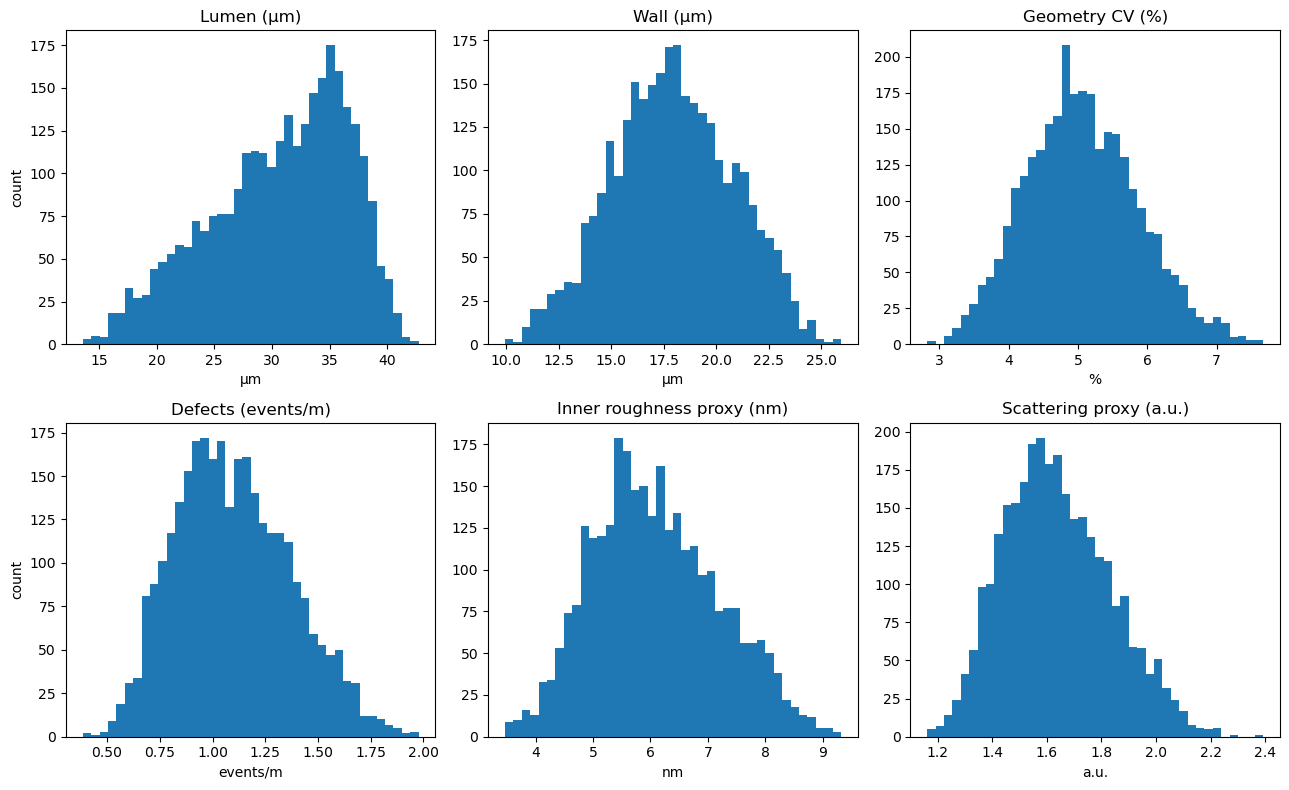

In [11]:
# Host manufacturing distributions
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.ravel()
axes[0].hist(df['lumen_um'], bins=40); axes[0].set_title('Lumen (µm)'); axes[0].set_xlabel('µm'); axes[0].set_ylabel('count')
axes[1].hist(df['wall_um'], bins=40); axes[1].set_title('Wall (µm)'); axes[1].set_xlabel('µm')
axes[2].hist(df['geom_cv_pct'], bins=40); axes[2].set_title('Geometry CV (%)'); axes[2].set_xlabel('%')
axes[3].hist(df['defects_per_m'], bins=40); axes[3].set_title('Defects (events/m)'); axes[3].set_xlabel('events/m'); axes[3].set_ylabel('count')
axes[4].hist(df['roughness_nm'], bins=40); axes[4].set_title('Inner roughness proxy (nm)'); axes[4].set_xlabel('nm')
axes[5].hist(df['scattering_au'], bins=40); axes[5].set_title('Scattering proxy (a.u.)'); axes[5].set_xlabel('a.u.')
plt.tight_layout(); plt.show()


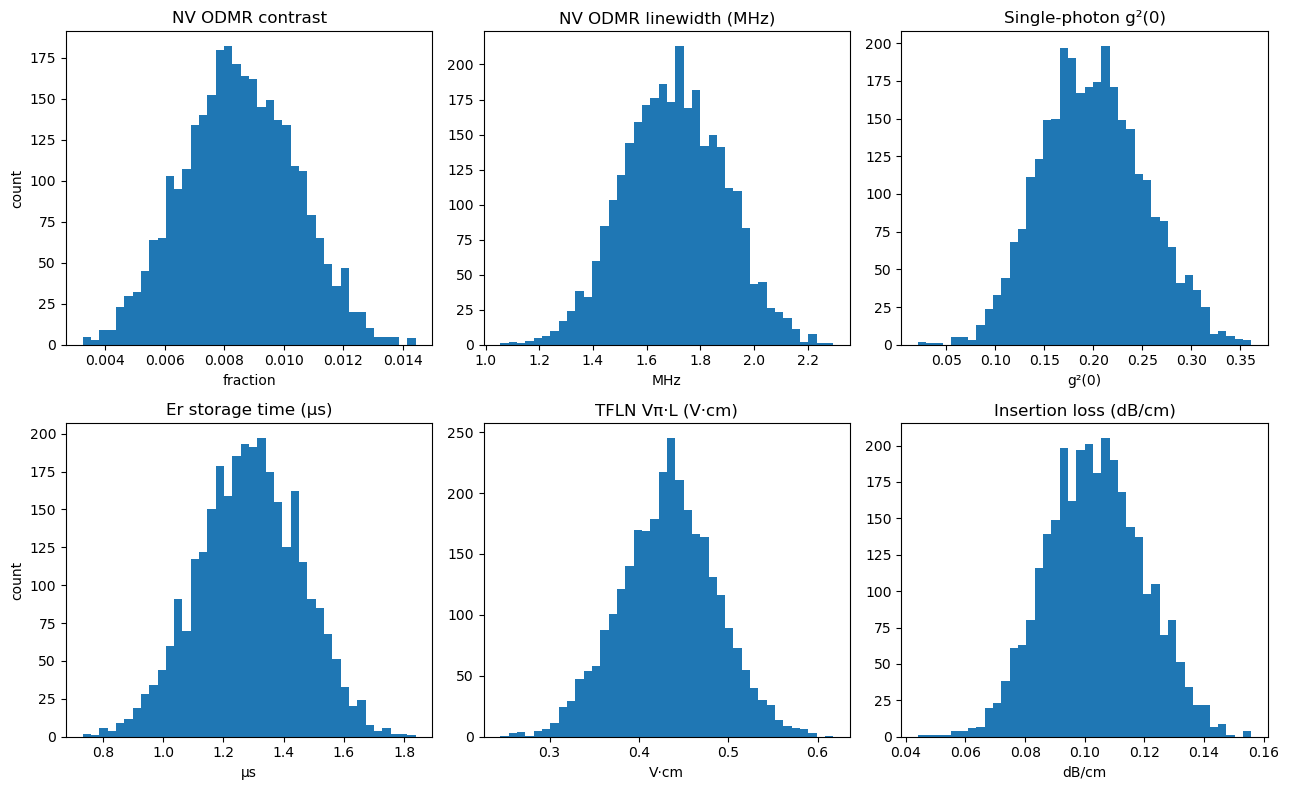

In [13]:
# Quantum metric distributions
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.ravel()
axes[0].hist(df['nv_odmr_contrast'], bins=40); axes[0].set_title('NV ODMR contrast'); axes[0].set_xlabel('fraction'); axes[0].set_ylabel('count')
axes[1].hist(df['nv_odmr_linewidth_mhz'], bins=40); axes[1].set_title('NV ODMR linewidth (MHz)'); axes[1].set_xlabel('MHz')
axes[2].hist(df['g2_0'], bins=40); axes[2].set_title('Single-photon g²(0)'); axes[2].set_xlabel('g²(0)')
axes[3].hist(df['er_storage_us'], bins=40); axes[3].set_title('Er storage time (µs)'); axes[3].set_xlabel('µs'); axes[3].set_ylabel('count')
axes[4].hist(df['tfln_vpiL_vcm'], bins=40); axes[4].set_title('TFLN Vπ·L (V·cm)'); axes[4].set_xlabel('V·cm')
axes[5].hist(df['insert_loss_db_per_cm'], bins=40); axes[5].set_title('Insertion loss (dB/cm)'); axes[5].set_xlabel('dB/cm')
plt.tight_layout(); plt.show()


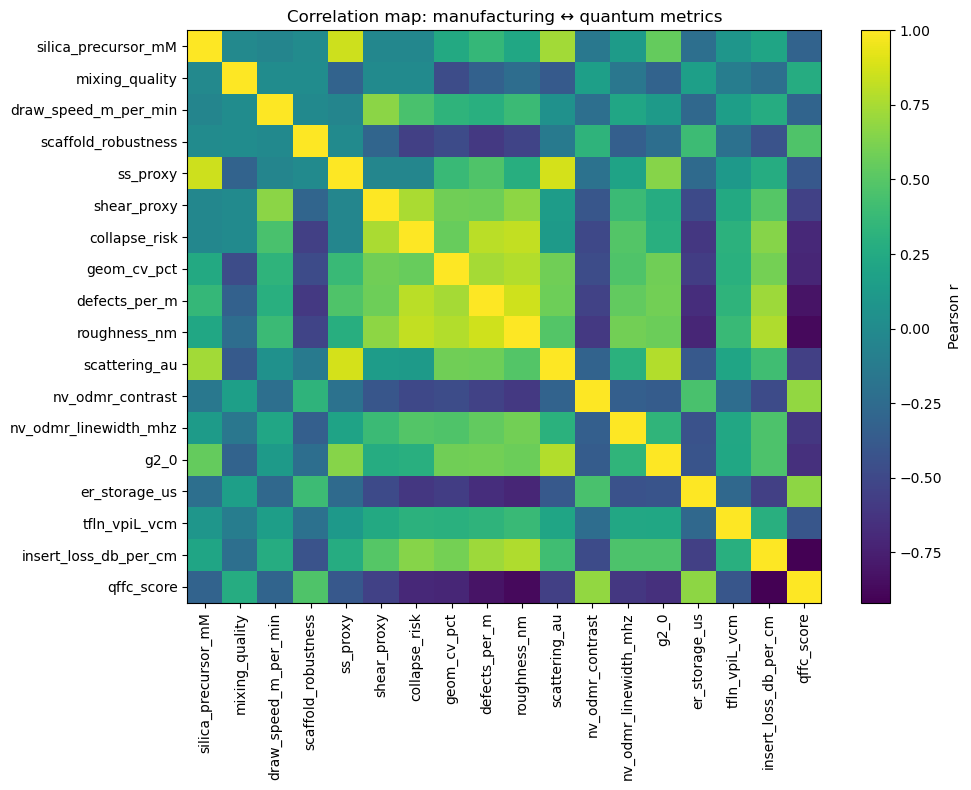

insert_loss_db_per_cm   -0.919
roughness_nm            -0.872
defects_per_m           -0.820
geom_cv_pct             -0.713
collapse_risk           -0.697
g2_0                    -0.652
nv_odmr_linewidth_mhz   -0.609
scattering_au           -0.557
shear_proxy             -0.547
tfln_vpiL_vcm           -0.407
ss_proxy                -0.390
silica_precursor_mM     -0.311
draw_speed_m_per_min    -0.298
mixing_quality           0.270
scaffold_robustness      0.468
er_storage_us            0.675
nv_odmr_contrast         0.692
qffc_score               1.000
Name: qffc_score, dtype: float64

In [15]:
# Correlation map between recipe/defects and quantum outcomes
cols = ['silica_precursor_mM','mixing_quality','draw_speed_m_per_min','scaffold_robustness',
        'ss_proxy','shear_proxy','collapse_risk','geom_cv_pct','defects_per_m','roughness_nm','scattering_au',
        'nv_odmr_contrast','nv_odmr_linewidth_mhz','g2_0','er_storage_us','tfln_vpiL_vcm','insert_loss_db_per_cm','qffc_score']
corr = df[cols].corr()
plt.figure(figsize=(10,8))
plt.imshow(corr, aspect='auto'); plt.colorbar(label='Pearson r')
plt.xticks(range(len(cols)), cols, rotation=90); plt.yticks(range(len(cols)), cols)
plt.title('Correlation map: manufacturing ↔ quantum metrics')
plt.tight_layout(); plt.show()
corr['qffc_score'].sort_values().round(3)


In [17]:
# Surrogate models: predict quantum metrics from controllable setpoints
features = ['pH','ionic_mM','temp_C','silica_precursor_mM','residence_s','draw_speed_m_per_min','tension_proxy','mixing_quality','scaffold_robustness']
targets = ['qffc_score','nv_odmr_contrast','nv_odmr_linewidth_mhz','g2_0','er_storage_us','tfln_vpiL_vcm','insert_loss_db_per_cm']

metrics = []
models = {}
for t in targets:
    X = df[features]; y = df[t]
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.22, random_state=7)
    m = RandomForestRegressor(n_estimators=600, random_state=7, min_samples_leaf=3, n_jobs=-1)
    m.fit(Xtr, ytr)
    pred = m.predict(Xte)
    models[t] = m
    metrics.append({'target':t, 'MAE':mean_absolute_error(yte, pred), 'R2':r2_score(yte, pred)})
pd.DataFrame(metrics).sort_values('R2', ascending=False).round(4)


,target,MAE,R2
0,qffc_score,0.7766,0.6294
3,g2_0,0.0305,0.5101
6,insert_loss_db_per_cm,0.0095,0.4728
4,er_storage_us,0.1043,0.4114
1,nv_odmr_contrast,0.0013,0.2913
2,nv_odmr_linewidth_mhz,0.1302,0.2622
5,tfln_vpiL_vcm,0.0415,0.0338


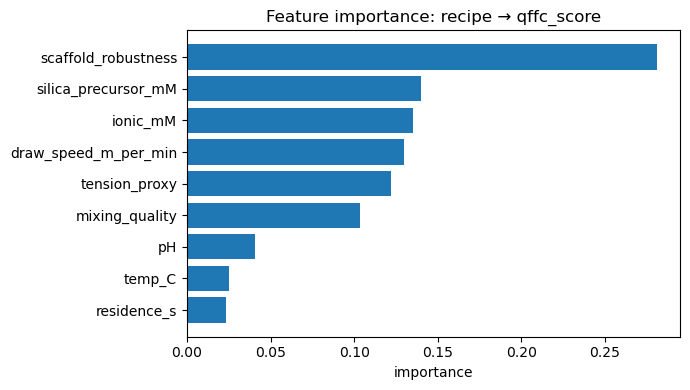

scaffold_robustness     0.280805
silica_precursor_mM     0.140097
ionic_mM                0.135060
draw_speed_m_per_min    0.130021
tension_proxy           0.122028
mixing_quality          0.103247
pH                      0.040640
temp_C                  0.024927
dtype: float64

In [18]:
# Feature importance for qffc_score
imp = pd.Series(models['qffc_score'].feature_importances_, index=features).sort_values()
plt.figure(figsize=(7,4))
plt.barh(imp.index, imp.values)
plt.title('Feature importance: recipe → qffc_score')
plt.xlabel('importance')
plt.tight_layout(); plt.show()
imp.sort_values(ascending=False).head(8)


In [19]:
# Define a practical QC gate for “quantum-ready fibre”
gate = (
    (df['defects_per_m'] <= 1.0) &
    (df['roughness_nm'] <= 6.0) &
    (df['g2_0'] <= 0.35) &
    (df['nv_odmr_contrast'] >= 0.008) &
    (df['nv_odmr_linewidth_mhz'] <= 3.0) &
    (df['er_storage_us'] >= 0.8) &
    (df['insert_loss_db_per_cm'] <= 0.2)
)
df['quantum_ready'] = gate.astype(int)
df['quantum_ready'].mean()


np.float64(0.30366666666666664)

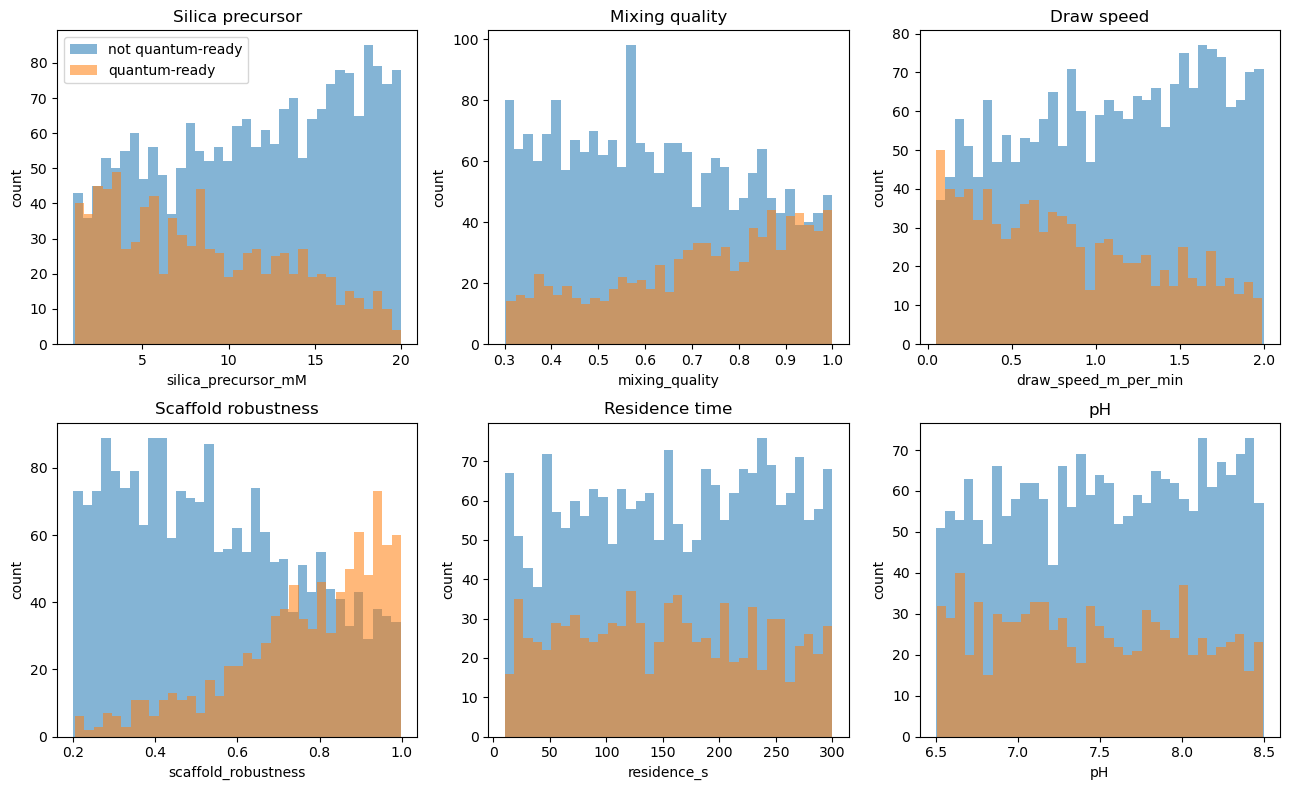

(0.30366666666666664, -5.876213665987701, -8.050748845828577)

In [23]:
# Compare recipes: quantum-ready vs not
good = df[df['quantum_ready']==1]
bad = df[df['quantum_ready']==0]

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.ravel()
for ax, col, title in [
    (axes[0],'silica_precursor_mM','Silica precursor'),
    (axes[1],'mixing_quality','Mixing quality'),
    (axes[2],'draw_speed_m_per_min','Draw speed'),
    (axes[3],'scaffold_robustness','Scaffold robustness'),
    (axes[4],'residence_s','Residence time'),
    (axes[5],'pH','pH'),
]:
    ax.hist(bad[col], bins=35, alpha=0.55, label='not quantum-ready')
    ax.hist(good[col], bins=35, alpha=0.55, label='quantum-ready')
    ax.set_title(title); ax.set_xlabel(col); ax.set_ylabel('count')
axes[0].legend()
plt.tight_layout(); plt.show()

(len(good)/len(df), good['qffc_score'].median(), bad['qffc_score'].median())


In [25]:
# Multi-objective recipe search by surrogate score (fast screening)
rng = np.random.default_rng(9)
def propose(n=15000):
    return pd.DataFrame({
        'pH': rng.uniform(6.8, 8.2, n),
        'ionic_mM': rng.uniform(40, 180, n),
        'temp_C': rng.uniform(20, 33, n),
        'silica_precursor_mM': rng.uniform(1, 14, n),
        'residence_s': rng.uniform(30, 220, n),
        'draw_speed_m_per_min': rng.uniform(0.05, 1.2, n),
        'tension_proxy': rng.uniform(0.3, 1.5, n),
        'mixing_quality': rng.uniform(0.55, 1.0, n),
        'scaffold_robustness': rng.uniform(0.5, 1.0, n),
    })

cand = propose()
cand['qffc_score_pred'] = models['qffc_score'].predict(cand[features])
top = cand.sort_values('qffc_score_pred', ascending=False).head(20)
top.round(3)


,pH,ionic_mM,temp_C,silica_precursor_mM,residence_s,draw_speed_m_per_min,tension_proxy,mixing_quality,scaffold_robustness,qffc_score_pred
10444,7.538,49.564,26.159,3.173,34.653,0.050,1.192,0.922,0.862,-4.064
12974,7.012,45.117,22.992,3.211,68.085,0.060,0.983,0.948,0.857,-4.066
3514,7.009,56.526,21.460,1.169,139.390,0.123,1.070,0.867,0.912,-4.090
11760,8.081,82.282,21.054,1.717,114.784,0.096,1.406,0.931,0.847,-4.143
14829,7.381,91.181,29.977,1.494,80.211,0.139,1.172,0.971,0.856,-4.160
13947,7.854,75.369,27.254,1.839,118.140,0.089,0.905,0.751,0.861,-4.161
3865,6.830,61.572,32.710,2.290,45.114,0.055,1.360,0.822,0.924,-4.182
12461,7.047,62.316,21.703,1.113,146.186,0.088,1.288,0.771,0.810,-4.183
5833,7.423,48.123,22.489,1.532,107.996,0.121,1.309,0.847,0.942,-4.193
13569,7.434,65.641,28.201,1.805,141.979,0.070,1.337,0.775,0.882,-4.206
